
# USGS Earthquake Data Preprocessing and Harmonization

## Overview
This notebook presents a complete preprocessing workflow for earthquake catalog data obtained from the United States Geological Survey (USGS) Earthquake Catalog. The workflow focuses on preparing raw seismic event data for further applications such as:

- Seismicity analysis
- Spatial and temporal earthquake studies
- Machine learning-based forecasting
- Seismic risk analytics
- Spatiotemporal pattern analysis

The preprocessing steps include:
- Merging multiple USGS catalog files
- Removing unnecessary metadata columns
- Extracting temporal features
- Standardizing coordinate and magnitude fields
- Magnitude harmonization
- Preparing a clean seismic dataset for downstream analysis

---

## Data Source

Earthquake data used in this study were collected from the official USGS Earthquake Catalog:

https://earthquake.usgs.gov/earthquakes/search/

The USGS catalog provides global earthquake records with detailed seismic parameters including:
- Magnitude
- Depth
- Latitude and Longitude
- Event time
- Magnitude type
- Event metadata

---

## About the Workflow

Earthquake catalogs often contain heterogeneous magnitude scales such as:
- Mw (Moment Magnitude)
- Mb (Body-wave Magnitude)
- Ms (Surface-wave Magnitude)
- Ml (Local Magnitude)

For scientific consistency and comparative analysis, magnitude harmonization is performed to convert different magnitude scales into a unified framework suitable for seismic analysis and machine learning workflows.

This notebook demonstrates a reproducible preprocessing pipeline for preparing earthquake data for research and analytics applications.


## 1. Import Required Libraries

In [1]:
from google.colab import drive

In [2]:

import pandas as pd
import numpy as np
import glob


## 2. Mount Google Drive

The preprocessing workflow is performed in Google Colab.  
Google Drive is mounted to access earthquake catalog CSV files and save processed outputs.


In [3]:
drive.mount('/content/drive')

Mounted at /content/drive



## 3. Merge Multiple USGS CSV Files

Multiple earthquake catalog files are combined into a single consolidated dataset.  
This step is useful when earthquake records are downloaded in batches due to catalog size limitations.


In [6]:

path = '/content/drive/MyDrive/Project 1/Data'

csv_files = glob.glob(path + "/*.csv")

df_list = (pd.read_csv(file) for file in csv_files)

con_df = pd.concat(df_list, ignore_index=False)

con_df.to_csv(
    "/content/drive/MyDrive/Project 1/usgs_data.csv",
    index=False
)

con_df.head()


,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,1966-01-01T06:02:04.180Z,19.068500,-155.166000,3.875,3.03,ml,9.0,269.0,NaN,0.10,...,2020-03-31T17:33:26.200Z,"36 km ESE of P?hala, Hawaii",earthquake,1.56,1.46,NaN,4.0,reviewed,hv,hv
1,1966-01-01T06:24:05.520Z,19.093500,-155.208333,9.805,2.93,ml,8.0,233.0,NaN,0.10,...,2020-03-31T17:33:26.360Z,"Island of Hawaii, Hawaii",earthquake,1.61,2.34,0.01,3.0,reviewed,hv,hv
2,1966-01-01T06:28:01.840Z,19.319000,-155.285667,0.905,2.72,ml,9.0,209.0,NaN,0.11,...,2020-03-31T17:33:26.500Z,"14 km SSW of Volcano, Hawaii",earthquake,1.07,0.61,0.06,5.0,reviewed,hv,hv
3,1966-01-01T13:23:39.000Z,42.842000,-78.249000,NaN,4.27,mw,NaN,NaN,NaN,NaN,...,2020-04-16T21:18:48.644Z,"3 km SE of Attica, New York",earthquake,NaN,NaN,NaN,NaN,reviewed,ushis,hrn
4,1966-01-01T20:37:55.270Z,19.336333,-155.216167,-0.345,2.53,ml,10.0,168.0,NaN,0.20,...,2020-03-31T17:38:54.590Z,"11 km S of Volcano, Hawaii",earthquake,0.94,0.42,0.13,2.0,reviewed,hv,hv



## 4. Load the Consolidated Earthquake Dataset

The merged earthquake catalog is loaded for preprocessing and transformation.


In [22]:

path2 = '/content/drive/MyDrive/Project 1/usgs_data.csv'

df1 = pd.read_csv(path2)

df1.head()


,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,1966-01-01T06:02:04.180Z,19.068500,-155.166000,3.875,3.03,ml,9.0,269.0,NaN,0.10,...,2020-03-31T17:33:26.200Z,"36 km ESE of P?hala, Hawaii",earthquake,1.56,1.46,NaN,4.0,reviewed,hv,hv
1,1966-01-01T06:24:05.520Z,19.093500,-155.208333,9.805,2.93,ml,8.0,233.0,NaN,0.10,...,2020-03-31T17:33:26.360Z,"Island of Hawaii, Hawaii",earthquake,1.61,2.34,0.01,3.0,reviewed,hv,hv
2,1966-01-01T06:28:01.840Z,19.319000,-155.285667,0.905,2.72,ml,9.0,209.0,NaN,0.11,...,2020-03-31T17:33:26.500Z,"14 km SSW of Volcano, Hawaii",earthquake,1.07,0.61,0.06,5.0,reviewed,hv,hv
3,1966-01-01T13:23:39.000Z,42.842000,-78.249000,NaN,4.27,mw,NaN,NaN,NaN,NaN,...,2020-04-16T21:18:48.644Z,"3 km SE of Attica, New York",earthquake,NaN,NaN,NaN,NaN,reviewed,ushis,hrn
4,1966-01-01T20:37:55.270Z,19.336333,-155.216167,-0.345,2.53,ml,10.0,168.0,NaN,0.20,...,2020-03-31T17:38:54.590Z,"11 km S of Volcano, Hawaii",earthquake,0.94,0.42,0.13,2.0,reviewed,hv,hv



## 5. Remove Unnecessary Metadata Columns

The raw USGS catalog contains several metadata attributes that are not required for the present analysis.  
These columns are removed to simplify the dataset and improve processing efficiency.


In [23]:

df1 = df1.drop(
    [
        'dmin', 'rms', 'net', 'id', 'updated',
        'place', 'type', 'horizontalError', 'depthError'
    ],
    axis=1
)

df1 = df1.drop(
    [
        'nst', 'gap', 'status', 'magNst',
        'locationSource', 'magSource', 'magError'
    ],
    axis=1
)

df1.head()


,time,latitude,longitude,depth,mag,magType
0,1966-01-01T06:02:04.180Z,19.068500,-155.166000,3.875,3.03,ml
1,1966-01-01T06:24:05.520Z,19.093500,-155.208333,9.805,2.93,ml
2,1966-01-01T06:28:01.840Z,19.319000,-155.285667,0.905,2.72,ml
3,1966-01-01T13:23:39.000Z,42.842000,-78.249000,NaN,4.27,mw
4,1966-01-01T20:37:55.270Z,19.336333,-155.216167,-0.345,2.53,ml



## 6. Extract Temporal Information

Earthquake occurrence time is separated into:
- Year
- Month
- Day
- Hour
- Minutes

These temporal variables are useful for:
- time-series analysis,
- seismicity trends,
- forecasting applications,
- temporal clustering studies.


In [24]:

df1[['Year', 'Month', 'Day']] = df1.time.str.split("-", expand=True)

df1[['Date', 'Time']] = df1.Day.str.split("T", expand=True)

df1[['Hour', 'Minutes', 'Todo2']] = df1.Time.str.split(":", expand=True)

df1[['seconds', 'Todo3']] = df1.Todo2.str.split(".", expand=True)

df1.head()


,time,latitude,longitude,depth,mag,magType,Year,Month,Day,Date,Time,Hour,Minutes,Todo2,seconds,Todo3
0,1966-01-01T06:02:04.180Z,19.068500,-155.166000,3.875,3.03,ml,1966,01,01T06:02:04.180Z,01,06:02:04.180Z,06,02,04.180Z,04,180Z
1,1966-01-01T06:24:05.520Z,19.093500,-155.208333,9.805,2.93,ml,1966,01,01T06:24:05.520Z,01,06:24:05.520Z,06,24,05.520Z,05,520Z
2,1966-01-01T06:28:01.840Z,19.319000,-155.285667,0.905,2.72,ml,1966,01,01T06:28:01.840Z,01,06:28:01.840Z,06,28,01.840Z,01,840Z
3,1966-01-01T13:23:39.000Z,42.842000,-78.249000,NaN,4.27,mw,1966,01,01T13:23:39.000Z,01,13:23:39.000Z,13,23,39.000Z,39,000Z
4,1966-01-01T20:37:55.270Z,19.336333,-155.216167,-0.345,2.53,ml,1966,01,01T20:37:55.270Z,01,20:37:55.270Z,20,37,55.270Z,55,270Z



## 7. Remove Intermediate Columns

Temporary columns generated during the time extraction process are removed.


In [25]:

df1 = df1.drop(['time'], axis=1)

df1 = df1.drop(['Day', 'Todo2', 'Todo3'], axis=1)

df1 = df1.drop(['Time'], axis=1)

df1.head()


,latitude,longitude,depth,mag,magType,Year,Month,Date,Hour,Minutes,seconds
0,19.068500,-155.166000,3.875,3.03,ml,1966,01,01,06,02,04
1,19.093500,-155.208333,9.805,2.93,ml,1966,01,01,06,24,05
2,19.319000,-155.285667,0.905,2.72,ml,1966,01,01,06,28,01
3,42.842000,-78.249000,NaN,4.27,mw,1966,01,01,13,23,39
4,19.336333,-155.216167,-0.345,2.53,ml,1966,01,01,20,37,55



## 8. Standardize Column Names

Column names are standardized for consistency and improved readability.


In [26]:

df1 = df1.rename(columns={'longitude': 'LON'})
df1 = df1.rename(columns={'latitude': 'LAT'})
df1 = df1.rename(columns={'mag': 'MAG'})
df1 = df1.rename(columns={'depth': 'DEPTH'})

df1.head()


,LAT,LON,DEPTH,MAG,magType,Year,Month,Date,Hour,Minutes,seconds
0,19.068500,-155.166000,3.875,3.03,ml,1966,01,01,06,02,04
1,19.093500,-155.208333,9.805,2.93,ml,1966,01,01,06,24,05
2,19.319000,-155.285667,0.905,2.72,ml,1966,01,01,06,28,01
3,42.842000,-78.249000,NaN,4.27,mw,1966,01,01,13,23,39
4,19.336333,-155.216167,-0.345,2.53,ml,1966,01,01,20,37,55



## 9. Reorganize Dataset Columns

The dataset columns are rearranged into a structured format suitable for seismic analysis workflows.


In [27]:

df1 = df1.reindex(
    columns=[
        'LON', 'LAT', 'Year', 'Month', 'Date',
        'MAG', 'DEPTH', 'Hour', 'Minutes',
        'seconds', 'magType'
    ]
)

df1 = df1.drop(['seconds'], axis=1)

df1.head()


,LON,LAT,Year,Month,Date,MAG,DEPTH,Hour,Minutes,magType
0,-155.166000,19.068500,1966,01,01,3.03,3.875,06,02,ml
1,-155.208333,19.093500,1966,01,01,2.93,9.805,06,24,ml
2,-155.285667,19.319000,1966,01,01,2.72,0.905,06,28,ml
3,-78.249000,42.842000,1966,01,01,4.27,NaN,13,23,mw
4,-155.216167,19.336333,1966,01,01,2.53,-0.345,20,37,ml



## 10. Convert Data Types

Temporal attributes are converted into integer format to support sorting and numerical operations.


In [28]:

df1['Year'] = df1['Year'].astype(int)
df1['Month'] = df1['Month'].astype(int)
df1['Date'] = df1['Date'].astype(int)

df1.head()


,LON,LAT,Year,Month,Date,MAG,DEPTH,Hour,Minutes,magType
0,-155.166000,19.068500,1966,1,1,3.03,3.875,06,02,ml
1,-155.208333,19.093500,1966,1,1,2.93,9.805,06,24,ml
2,-155.285667,19.319000,1966,1,1,2.72,0.905,06,28,ml
3,-78.249000,42.842000,1966,1,1,4.27,NaN,13,23,mw
4,-155.216167,19.336333,1966,1,1,2.53,-0.345,20,37,ml



## 11. Sort Earthquake Events Chronologically

Earthquake records are sorted according to:
- Year
- Month
- Day
- Hour
- Minutes


In [29]:

df2 = df1.sort_values(
    by=['Year', 'Month', 'Date', 'Hour', 'Minutes']
)

df2.head()


,LON,LAT,Year,Month,Date,MAG,DEPTH,Hour,Minutes,magType
0,-155.166000,19.068500,1966,1,1,3.03,3.875,06,02,ml
1,-155.208333,19.093500,1966,1,1,2.93,9.805,06,24,ml
2,-155.285667,19.319000,1966,1,1,2.72,0.905,06,28,ml
3,-78.249000,42.842000,1966,1,1,4.27,NaN,13,23,mw
4,-155.216167,19.336333,1966,1,1,2.53,-0.345,20,37,ml



## 12. Generate Decimal Time Representation

A decimal year representation is generated for temporal analysis and machine learning applications.

Example:
- Mid-2020 may be represented as approximately 2020.5


In [30]:

def calculate_year_decimal(year, month, day):

    if month in [1, 3, 5, 7, 8, 10, 12]:
        return year + (month - 1 + day / 31) / 12

    elif month in [4, 6, 9, 11]:
        return year + (month - 1 + day / 30) / 12

    else:
        if (year % 4) == 0:
            return year + (month - 1 + day / 29) / 12
        else:
            return year + (month - 1 + day / 28) / 12


df2['Time (years)'] = df2.apply(
    lambda row: calculate_year_decimal(
        row['Year'],
        row['Month'],
        row['Date']
    ),
    axis=1
)

df2['Time (years)'] = df2['Time (years)'].round(4)

df2.head()


,LON,LAT,Year,Month,Date,MAG,DEPTH,Hour,Minutes,magType,Time (years)
0,-155.166000,19.068500,1966,1,1,3.03,3.875,06,02,ml,1966.0027
1,-155.208333,19.093500,1966,1,1,2.93,9.805,06,24,ml,1966.0027
2,-155.285667,19.319000,1966,1,1,2.72,0.905,06,28,ml,1966.0027
3,-78.249000,42.842000,1966,1,1,4.27,NaN,13,23,mw,1966.0027
4,-155.216167,19.336333,1966,1,1,2.53,-0.345,20,37,ml,1966.0027



## 13. Inspect Magnitude Types

Earthquake catalogs contain different magnitude scales depending on seismic networks and event characteristics.


In [31]:
df2.magType.unique()

array(['ml', 'mw', 'mh', 'mb', 'lg', 'ma', 'md', 'ms', nan, 'mlg'],
      dtype=object)


## 14. Magnitude Harmonization

Different magnitude scales are standardized to maintain consistency across the earthquake catalog.

This step is important because:
- multiple seismic networks use different magnitude scales,
- machine learning models require consistent inputs,
- comparative seismic analysis becomes more reliable.

The workflow converts several magnitude types into unified representations.


In [34]:

df2['magType'] = df2['magType'].replace(
    {
        'ml': 'Mw',
        'Ml': 'Mw',
        'mlr': 'Mw',
        'mww': 'Mw',
        'mwb': 'Mw'
    }
)

df2['magType'] = df2['magType'].replace(
    {
        'mc': 'Mw',
        'Md': 'Mw',
        'mwc': 'Mw',
        'md': 'Mw',
        'mb': 'Mb'
    }
)

df2['magType'] = df2['magType'].replace(
    {
        'mw': 'Mw',
        'mwr': 'Mw',
        'mwp': 'Mw',
        'mlv': 'Mw',
        'mb_lg': 'Mb'
    }
)

df2['magType'] = df2['magType'].replace(
    {
        'mh': 'Mw',
        'mlg': 'Mw',
        'ms_20': 'Ms',
        'lg': 'Mw',
        'ms': 'Ms',
        'ma': 'Mw'
    }
)

df2.magType.unique()


array(['Mw', 'Mb', 'Ms', nan], dtype=object)


## 15. Remove Invalid or Unknown Magnitude Types

Rows with missing or undefined magnitude types are removed to maintain data quality.


In [35]:

df2 = df2.drop(index=df2[df2['magType'] == 'Unknown'].index)

df2 = df2.drop(index=df2[df2['magType'] == 'nan'].index)

df2.dropna(axis=0, how='all', inplace=True)

df2.dropna(subset=['magType'], how='any', inplace=True)

df2.magType.unique()


array(['Mw', 'Mb', 'Ms'], dtype=object)


## 16. Convert Magnitudes into Unified Representation

Empirical relationships are used to convert different magnitude scales into a harmonized magnitude framework.

This step improves consistency for:
- seismicity analysis,
- forecasting studies,
- statistical modeling,
- machine learning applications.


In [36]:

def calculate_mag_decimal(magType, mag):

    if magType == 'Mb':
        return (0.85 * mag + 1.03)

    elif magType == 'Ms':

        if ((mag >= 3) and (mag < 6.1)):
            return (0.67 * mag + 2.07)

        else:
            return (0.99 * mag + 0.08)

    else:
        return mag


df2['MAG2'] = df2.apply(
    lambda row: calculate_mag_decimal(
        row['magType'],
        row['MAG']
    ),
    axis=1
)

df2.head()


,LON,LAT,Year,Month,Date,MAG,DEPTH,Hour,Minutes,magType,Time (years),MAG2
0,-155.166000,19.068500,1966,1,1,3.03,3.875,06,02,Mw,1966.0027,3.03
1,-155.208333,19.093500,1966,1,1,2.93,9.805,06,24,Mw,1966.0027,2.93
2,-155.285667,19.319000,1966,1,1,2.72,0.905,06,28,Mw,1966.0027,2.72
3,-78.249000,42.842000,1966,1,1,4.27,NaN,13,23,Mw,1966.0027,4.27
4,-155.216167,19.336333,1966,1,1,2.53,-0.345,20,37,Mw,1966.0027,2.53



## 17. Final Dataset Formatting

The processed earthquake catalog is reorganized and rounded for consistency.


In [37]:

df2 = df2.drop(['MAG', 'magType'], axis=1)

df2 = df2.reindex(
    columns=[
        'LON', 'LAT', 'Year', 'Month',
        'Date', 'MAG2', 'DEPTH',
        'Hour', 'Minutes', 'Time (years)'
    ]
)

df2['MAG2'] = df2['MAG2'].round(1)

df2 = df2.rename(columns={'MAG2': 'MAG'})

df2.head()


,LON,LAT,Year,Month,Date,MAG,DEPTH,Hour,Minutes,Time (years)
0,-155.166000,19.068500,1966,1,1,3.0,3.875,06,02,1966.0027
1,-155.208333,19.093500,1966,1,1,2.9,9.805,06,24,1966.0027
2,-155.285667,19.319000,1966,1,1,2.7,0.905,06,28,1966.0027
3,-78.249000,42.842000,1966,1,1,4.3,NaN,13,23,1966.0027
4,-155.216167,19.336333,1966,1,1,2.5,-0.345,20,37,1966.0027



## 18. Export Processed Dataset

The final processed earthquake catalog is exported as a CSV file for further analysis and modeling.


In [38]:

df2.to_csv(
    "/content/drive/MyDrive/Project 1/usgs_data_2.csv",
    index=False
)

print("Processed earthquake catalog exported successfully.")


Processed earthquake catalog exported successfully.


## 19. Spatial Distribution of Earthquake Events

This visualization shows the spatial distribution of earthquake events using longitude and latitude coordinates.

The plot helps in:
- identifying seismic activity zones,
- observing regional clustering patterns,
- understanding geographical distribution of earthquake events.

Longitude and latitude information are fundamental parameters in spatiotemporal seismic analysis and geospatial analytics.

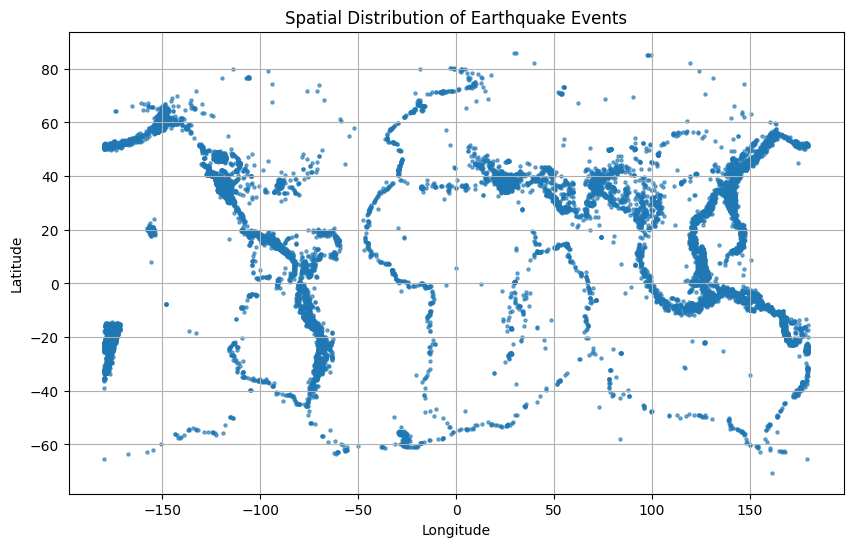

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    df2['LON'],
    df2['LAT'],
    s=5,
    alpha=0.6
)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Spatial Distribution of Earthquake Events')

plt.grid(True)

plt.savefig(
    "/content/drive/MyDrive/Project 1/Output/Spatial_Distribution_Long_vs_Lat.png",
    dpi=600,
    bbox_inches='tight'
)

plt.show()

## 20. Magnitude Variation Across Spatial Coordinates

This plot visualizes earthquake magnitudes across spatial coordinates using longitude and latitude values.

Magnitude-based visualization helps in:
- identifying high-magnitude seismic regions,
- understanding spatial variation of seismic intensity,
- analyzing regional earthquake behavior.

Color intensity represents earthquake magnitude.

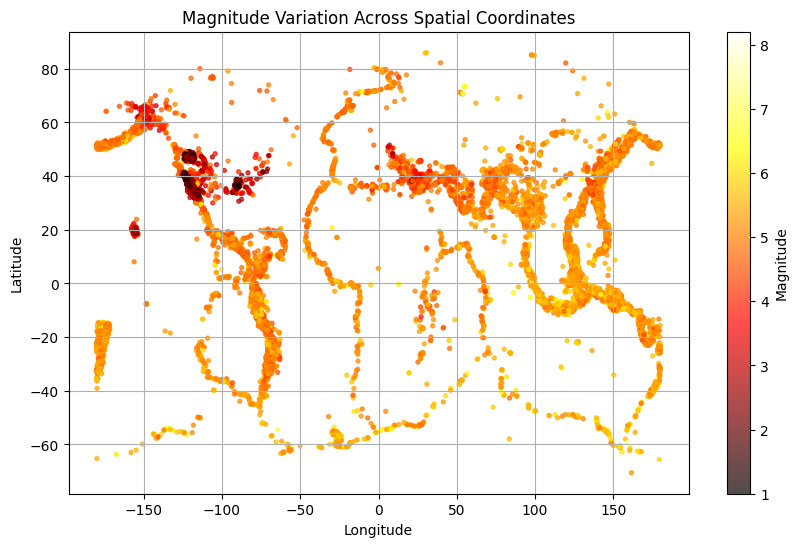

In [43]:
plt.figure(figsize=(10,6))

scatter = plt.scatter(
    df2['LON'],
    df2['LAT'],
    c=df2['MAG'],
    cmap='hot',
    s=8,
    alpha=0.7
)

plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.title('Magnitude Variation Across Spatial Coordinates')

cbar = plt.colorbar(scatter)
cbar.set_label('Magnitude')

plt.grid(True)

plt.savefig(
    "/content/drive/MyDrive/Project 1/Output/Magnitude_Variation_Long_Lat.png",
    dpi=600,
    bbox_inches='tight'
)

plt.show()

## 21. Depth Variation Across Spatial Coordinates

This visualization represents earthquake depth variation across geographical coordinates.

Depth analysis is important for:
- identifying shallow and deep-focus earthquakes,
- understanding tectonic activity,
- analyzing subsurface seismic behavior.

Color intensity represents earthquake depth in kilometers.

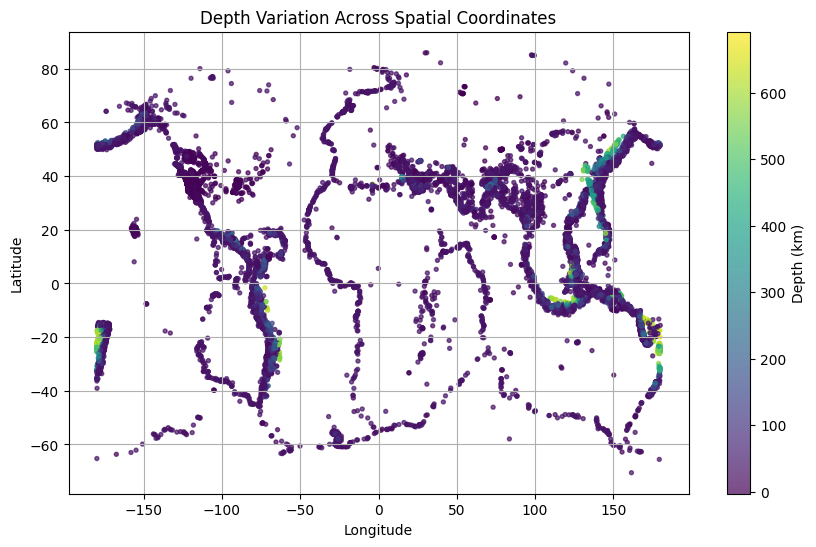

In [44]:
plt.figure(figsize=(10,6))

scatter = plt.scatter(
    df2['LON'],
    df2['LAT'],
    c=df2['DEPTH'],
    cmap='viridis',
    s=8,
    alpha=0.7
)

plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.title('Depth Variation Across Spatial Coordinates')

cbar = plt.colorbar(scatter)
cbar.set_label('Depth (km)')

plt.grid(True)

plt.savefig(
    "/content/drive/MyDrive/Project 1/Output/Depth_Variation_Long_Lat.png",
    dpi=600,
    bbox_inches='tight'
)

plt.show()

## 22. Temporal Variation of Earthquake Magnitude

This plot illustrates the variation of earthquake magnitudes with decimal year representation.

Temporal seismic analysis helps in:
- identifying seismic trends,
- understanding temporal clustering,
- studying earthquake occurrence behavior over time.

Decimal year representation improves visualization and time-series analysis.

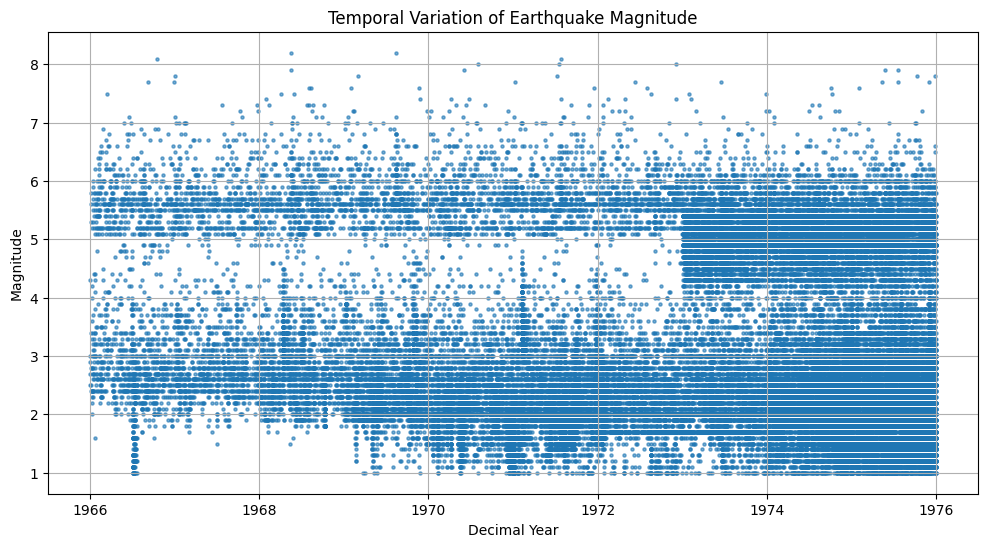

In [45]:
plt.figure(figsize=(12,6))

plt.scatter(
    df2['Time (years)'],
    df2['MAG'],
    s=5,
    alpha=0.6
)

plt.xlabel('Decimal Year')
plt.ylabel('Magnitude')

plt.title('Temporal Variation of Earthquake Magnitude')

plt.grid(True)

plt.savefig(
    "/content/drive/MyDrive/Project 1/Output/Decimal_Year_vs_Magnitude.png",
    dpi=600,
    bbox_inches='tight'
)

plt.show()




# Future Applications

The processed earthquake catalog generated through this workflow can be used for:

- Seismic energy analysis
- Time-series forecasting
- Machine learning models
- Spatiotemporal seismic studies
- Earthquake clustering analysis
- Risk assessment studies
- Seismic hazard analytics

---

# Related Publications

1. Yarramsetty, B. B., & Baladhandapani, K. (2026). *Machine Learning Models for Seismic Energy Forecasting and Spatial Correlation Analysis for the Himalayan and Indo-Burmese Regions*. Natural Hazards Review, 27(3). https://doi.org/10.1061/NHREFO.NHENG-2647

2. Yarramsetty, B. B., & Baladhandapani, K. (2026). *Data-driven prediction of global annual seismic energy using machine learning models*. Journal of Earth System Science, 135(2), 60. https://doi.org/10.1007/s12040-026-02788-2

3. Bala Balaji, Y., Hema Sundara, R. V., & Kavitha, B. (2025). *Spatial Variation of Seismic Energy Release of Himachal Pradesh*. Disaster Advances, 3(19), 15. https://doi.org/10.25303/193da15023

4. Yarramsetty, B. B., & Kavitha, B. (2025). *Statistical Study on Seismicity of the Indian Tectonic Plate Interactions*. Disaster Advances, 10(18), 12. https://doi.org/10.25303/1810da012021

---

# Citation

If you use this preprocessing workflow, code structure, or repository in your research or academic work, please consider citing the related publications listed above.

---

# Author

Bala Balaji Y  
Applied ML Researcher | Seismic Data Analytics | Spatiotemporal Forecasting


# Collaboration Opportunities

I am open to academic, research, and industry collaborations related to:

- Seismic data analytics
- Spatiotemporal modeling
- Earthquake forecasting
- Machine learning applications in geoscience
- Risk analytics and predictive modeling
- AI-driven scientific data workflows.
- Scientific data engineering workflows

And related areas

Researchers, students, and professionals interested in collaborative work are welcome to connect and contribute.